In [1]:
import equinox as eqx
import grain
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from context_flux_no.data.sources import WellDatasetSourceBase, ZarrWellDatasetSource
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DISCO,
    DPOT,
)
from context_flux_no.models.multiphysics.hyperfluxfno import (
    HyperFluxFNOLocal,
    HyperNeuralOperator,
    HyperNeuralOperatorv2
)
from context_flux_no.training.trainer import Trainer
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_default_device", jax.devices("gpu")[6])

In [2]:
transforms = [grain.transforms.Batch(batch_size=64)]
source_train = ZarrWellDatasetSource(
    "../../data/datasets",
    "euler_2d",
    "train",
    window_size=21,
    preload_into_ram=True,
)
dataloader = grain.DataLoader(
    data_source=source_train,
    sampler=grain.samplers.IndexSampler(len(source_train), shuffle=True, seed=0),
    operations=transforms,
    worker_count=0,
)
source_valid = ZarrWellDatasetSource(
    "../../data/datasets",
    "euler_2d",
    "valid",
    window_size=21,
    preload_into_ram=True,
)
dataloader_valid = grain.DataLoader(
    data_source=source_valid,
    sampler=grain.samplers.IndexSampler(len(source_valid), shuffle=True, seed=1),
    operations=transforms,
    worker_count=0,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)

dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('rho', 'E'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1
dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('rho', 'E'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1
dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('rho', 'E'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1


In [3]:
dataiter = iter(dataloader)
batch = next(dataiter)

In [4]:
(batch.dtype.itemsize * batch.size) / 1e9

0.352321536

In [5]:
batch.shape

(64, 21, 4, 128, 128)

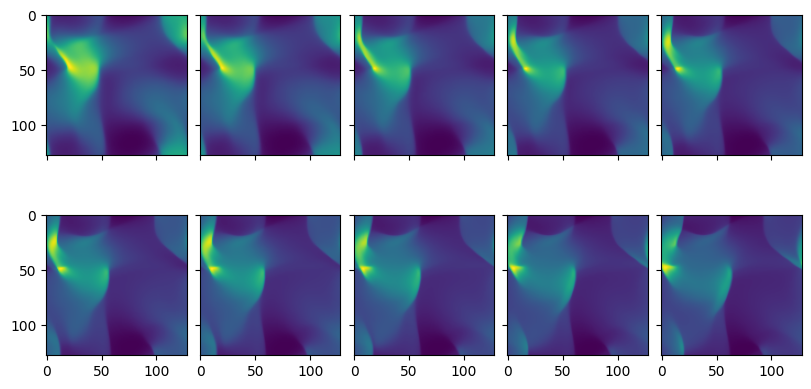

In [9]:
sample_idx = 5
fig, axes = plt.subplots(
    2, 5, figsize=(8, 4), constrained_layout=True, sharex=True, sharey=True
)
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[sample_idx, i * 2, 1])

In [ ]:
dpot = DPOT(
    num_spatial_dims=2,
    in_channels=5,
    out_channels=5,
    in_timesteps=10,
    grid_size=(64, 64),
    patch_size=(8, 8),
    embedding_dim=128,
    max_frequency_modes=(10, 10),
    fno_depth=10,
    num_blocks=8,
    hidden_dim_patch=512,
    hidden_dim_fno=512,
    hidden_dim_output=512,
    key=jax.random.key(0),
)
print(dpot.num_parameters() / 1e6)

6.293509


In [ ]:
hyperfluxfno = HyperFluxFNOLocal(
    num_spatial_dims=2,
    in_channels=5,
    in_timesteps=10,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(64, 64),
        patch_size=(8, 8),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    depth=5,
    lift_dim=128,
    stencil_size=(8, 8),
    width_hyper=128,
    blocks_hyper=4,
    key=jax.random.key(0),
)
print(hyperfluxfno.num_parameters() / 1e6)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/utils.py:53: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(


6.718728


In [ ]:
disco = DISCO(
    num_spatial_dims=2,
    channels=5,
    embedding_dim=128,
    patch_size=8,
    num_hypernet_blocks=3,
    droppath=0.1,
    num_hypernet_heads=8,
    mlp_hidden_dim=32,
    boundary_condition="periodic",
    opnet_hidden_channels=8,
    opnet_norm_groups=4,
    rtol=1e-4,
    atol=1e-6,
    max_steps=16,
    key=jax.random.key(0),
)
print(disco.num_parameters() / 1e6)

6.62227


In [12]:
hyperfluxfno = HyperNeuralOperator(
    num_spatial_dims=2,
    in_channels=4,
    in_timesteps=20,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(128, 128),
        patch_size=(8, 8),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    target_network_type="FluxNO",
    target_network_kwargs=dict(
        stencil_widths=(8, 8), lift_dim=128, hidden_dim=128, depth=5
    ),
    lift_dim=None,
    width_hyper=128,
    blocks_hyper=4,
    key=jax.random.key(0),
)
print(hyperfluxfno.num_parameters() / 1e6)

6.743304


In [4]:
hyperfluxfno2 = HyperNeuralOperator(
    num_spatial_dims=2,
    in_channels=4,
    in_timesteps=20,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(128, 128),
        patch_size=(8, 8),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    target_network_type="NDFluxNO",
    target_network_kwargs=dict(
        normal_stencil_halfwidths=(8, 8), transverse_stencil_halfwidth=6, lift_dim=128, hidden_dim=128, depth=4, stack_grid=False
    ),
    lift_dim=None,
    width_hyper=128,
    blocks_hyper=4,
    key=jax.random.key(0),
)
print(hyperfluxfno2.num_parameters() / 1e6)

6.342536


In [ ]:
hyperfluxfno2(jnp.ones((21, 4, 128, 128)), (0.01, 1 / 128, 1 / 128))

(Array([[[1.0017166 , 1.0487174 , 1.0684465 , ..., 1.0042918 ,
          1.0631361 , 1.0725362 ],
         [0.9633095 , 1.0025053 , 1.0471661 , ..., 0.978164  ,
          1.0306627 , 1.0295072 ],
         [0.9540231 , 0.9763387 , 1.0166653 , ..., 0.96933675,
          1.0203915 , 1.0203226 ],
         ...,
         [0.93231094, 0.96252126, 0.9968888 , ..., 0.9463832 ,
          1.0052755 , 1.0027093 ],
         [0.9595382 , 0.9956442 , 1.0333475 , ..., 0.96327037,
          1.0213317 , 1.0284408 ],
         [0.90708375, 0.94308287, 0.9787517 , ..., 0.91365343,
          0.9768889 , 0.9689606 ]],
 
        [[0.97446203, 0.9318428 , 1.0344087 , ..., 0.8861907 ,
          0.9620187 , 1.0698007 ],
         [0.99214315, 0.94692194, 1.0533512 , ..., 0.9648764 ,
          1.0239948 , 1.125624  ],
         [0.97551656, 0.9486458 , 1.043698  , ..., 0.9254906 ,
          0.99163055, 1.1023724 ],
         ...,
         [0.99318814, 0.9421169 , 1.0368726 , ..., 0.91872925,
          1.001678  , 1.

In [2]:
hyperfluxfno3 = HyperNeuralOperator(
    num_spatial_dims=2,
    in_channels=4,
    in_timesteps=20,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(128, 128),
        patch_size=(8, 8),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    target_network_type="ConvNextFluxNO",
    target_network_kwargs=dict(lift_dim=64, kernel_size=5, depth=4),
    lift_dim=None,
    width_hyper=128,
    blocks_hyper=4,
    key=jax.random.key(0),
)
print(hyperfluxfno3.num_parameters() / 1e6)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/utils.py:73: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(


6.192072


In [2]:
hyperfluxfno = HyperNeuralOperatorv2(
    num_spatial_dims=2,
    in_channels=4,
    in_timesteps=20,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(128, 128),
        patch_size=(8, 8),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    normal_stencil_halfwidths=(4, 4),
    transverse_stencil_halfwidth=2,
    reconstructions_per_channel = 16,
    depth_target = 6,
    hidden_dim = 128,
    width_hyper=128,
    blocks_hyper=2,
    hypernet_init = "bias-hyperinit",
    key=jax.random.key(0),
)
print(hyperfluxfno.num_parameters() / 1e6)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/utils.py:73: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(


6.372888


In [14]:
def get_loss_args(source: WellDatasetSourceBase):
    dt = source.metadata_common["temporal_resolution"]
    dxs = source.metadata_common["spatial_resolution"]
    return (dt, *dxs)

In [15]:
args = get_loss_args(source_train)
compiled = (
    eqx.filter_jit(lambda model, x, args_, key: model(x, args_, key=key))
    .lower(hyperfluxfno, batch[0, :-1], args, jax.random.key(0))
    .compile()
)
flops = compiled.compiled.cost_analysis()["flops"] / 1e9
print(flops)

4.809488896


In [16]:
eqx.filter_vmap(hyperfluxfno, in_axes=(0, None))(batch[:, :-1], args)[
    0
].block_until_ready()

W0920 20:48:52.138345  503952 hlo_rematerialization.cc:3297] Can't reduce memory use below 59.77GiB (64181124465 bytes) by rematerialization; only reduced to 65.51GiB (70339002400 bytes), down from 65.51GiB (70339002400 bytes) originally
W0920 20:48:52.499936  503905 bfc_allocator.cc:371] Allocator (GPU_0_bfc) ran out of memory trying to allocate 65.02GiB from the lower end with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0920 20:48:59.610510  503920 hlo_rematerialization.cc:3297] Can't reduce memory use below 59.77GiB (64181124465 bytes) by rematerialization; only reduced to 65.51GiB (70339002400 bytes), down from 65.51GiB (70339002400 bytes) originally
W0920 20:48:59.975139  503953 bfc_allocator.cc:371] Allocator (GPU_0_bfc) ran out of memory trying to allocate 65.02GiB from the lower end with freed_by_count=0. The caller indicates that this is not a failure, but this may me

Array(shape=(64, 4, 128, 128), dtype=float32)

In [21]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    u: Float[Array, "batch time dim ..."],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred: Float[Array, "batch dim ..."] = eqx.filter_vmap(
        lambda u_, key_: model(u_, args, key=key_)
    )(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


trainer = Trainer(
    optax.adamw(1e-3),
    loss_fn,
    "./",
    None,
    {"entity": "jhko725", "project": "euler_test"},
    config_dict={"model": ""},
)

In [ ]:
trainer.train(
    hyperfluxfno3,
    dataloader,
    dataloader_valid,
    get_loss_args(source_train),
    num_steps=500,
    seed=0,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.
wandb: Currently logged in as: jhko725 (jhelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


E0907 19:24:51.019008 2003850 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.154 = f32[64,128]{1,0} fusion(slice.231, dynamic_nodonate__first___74_.1), kind=kCustom, calls=gemm_fusion_dot_general.154_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0907 19:24:51.019101 2003850 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.154_computation.clone {
  parameter_0.57 = f32[64,128]{1,0} parameter(0)
  parameter_1.57 = f32[128,128]{1,0} parameter(1)
  ROOT dot_general.1 = f32[64,128]{1,0} dot(parameter_0.57, parameter_1.57), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]

Step: 1 | Train loss: 0.0032199181150645018 | Valid loss: 
            0.0031468654051423073
Step: 2 | Train loss: 0.002701527439057827 | Valid loss: 
            0.0024226983077824116


Step: 3 | Train loss: 0.002476159483194351 | Valid loss: 
            0.0024975750129669905


Step: 4 | Train loss: 0.0019540186040103436 | Valid loss: 
            0.0022360600996762514


...

Step: 497 | Train loss: 0.0008116146782413125 | Valid loss: 
            0.0010823605116456747


Step: 498 | Train loss: 0.000851374352350831 | Valid loss: 
            0.0008291885023936629


Step: 499 | Train loss: 0.0007417708402499557 | Valid loss: 
            0.0007519809296354651


Step: 500 | Train loss: 0.0008078184328041971 | Valid loss: 
            0.000921334489248693


train_loss,█▅▅▃▃▂▁▁▁▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂
valid_loss,█▇█▅▆▄▃▂▂▁▂▁▂▂▁▂▂▁▁▂▃▃▁▁▂▁▂▁▁▂▁▁▁▂▁▁▁▁▁▁
train_loss,0.00081
valid_loss,0.00092
